In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/raw/ai4i2020.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

In [4]:
window = 5

for col in sensor_cols:
    df[f'{col}_roll_mean'] = df[col].rolling(window=window, min_periods=1).mean()
    df[f'{col}_roll_std']  = df[col].rolling(window=window, min_periods=1).std().fillna(0)
    df[f'{col}_roll_var']  = df[col].rolling(window=window, min_periods=1).var().fillna(0)

print("New shape:", df.shape)
print("New columns added:", [c for c in df.columns if 'roll' in c])

New shape: (10000, 29)
New columns added: ['Air temperature [K]_roll_mean', 'Air temperature [K]_roll_std', 'Air temperature [K]_roll_var', 'Process temperature [K]_roll_mean', 'Process temperature [K]_roll_std', 'Process temperature [K]_roll_var', 'Rotational speed [rpm]_roll_mean', 'Rotational speed [rpm]_roll_std', 'Rotational speed [rpm]_roll_var', 'Torque [Nm]_roll_mean', 'Torque [Nm]_roll_std', 'Torque [Nm]_roll_var', 'Tool wear [min]_roll_mean', 'Tool wear [min]_roll_std', 'Tool wear [min]_roll_var']


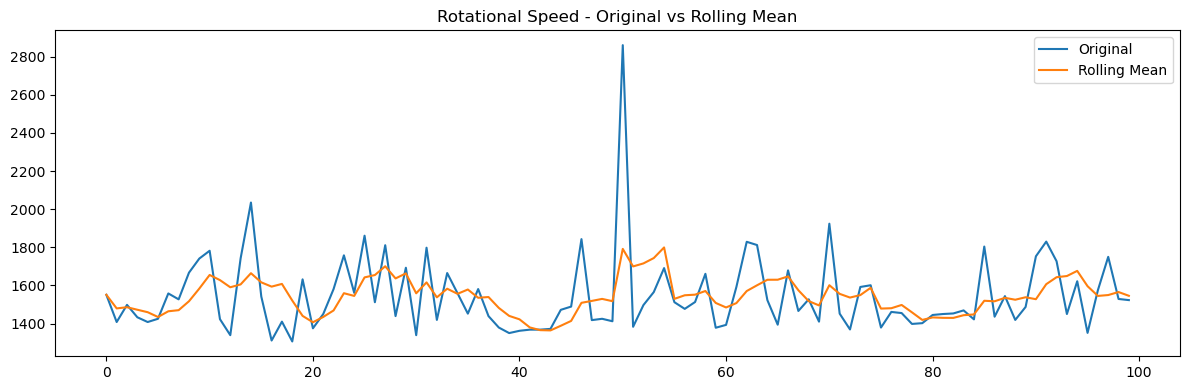

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(df['Rotational speed [rpm]'][:100], label='Original')
plt.plot(df['Rotational speed [rpm]_roll_mean'][:100], label='Rolling Mean')
plt.title('Rotational Speed - Original vs Rolling Mean')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("../data/processed/ai4i2020_features.csv", index=False)
print("Saved! Total features:", df.shape[1])

Saved! Total features: 29
